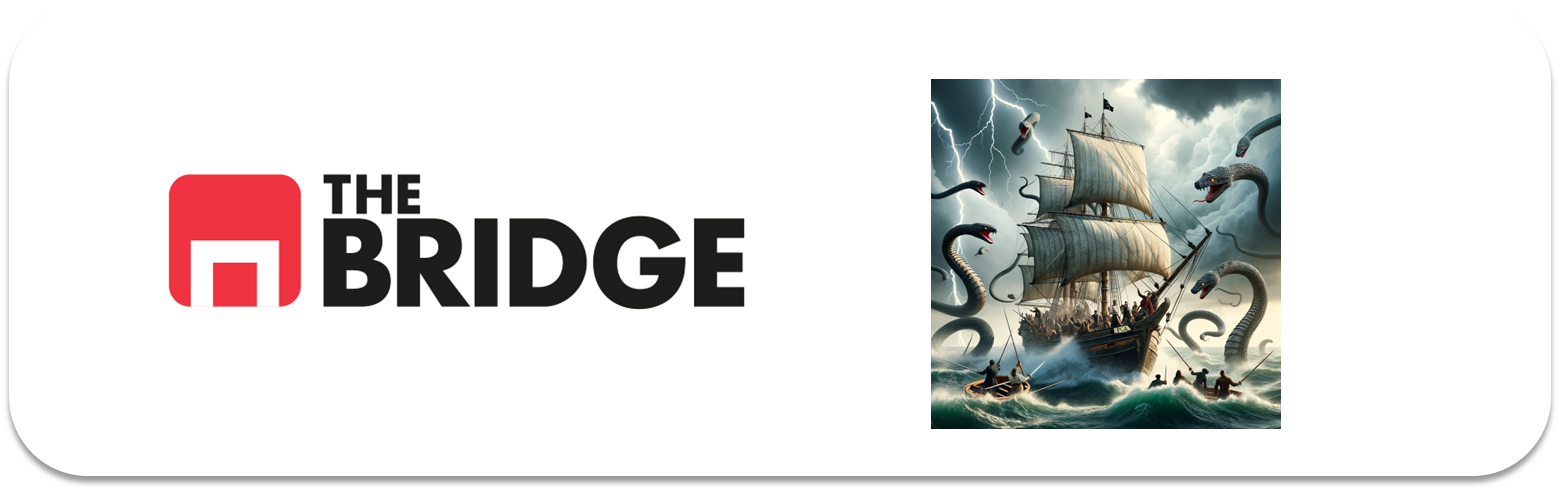

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técncias de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, silhouette_samples, balanced_accuracy_score,
                             accuracy_score, adjusted_rand_score, normalized_mutual_info_score)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
from threadpoolctl import threadpool_limits
threadpool_limits(2)
SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

from sklearn.feature_selection import (SelectKBest, f_classif, mutual_info_classif,
    SelectFromModel, RFE, SequentialFeatureSelector, VarianceThreshold)
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED)

### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


SeriousDlqin2yrs                          0
RevolvingUtilizationOfUnsecuredLines      0
age                                       0
NumberOfTime30-59DaysPastDueNotWorse      0
DebtRatio                                 0
MonthlyIncome                           721
NumberOfOpenCreditLinesAndLoans           0
NumberOfTimes90DaysLate                   0
NumberRealEstateLoansOrLines              0
NumberOfTime60-89DaysPastDueNotWorse      0
NumberOfDependents                      177
dtype: int64

Filas iniciales y completas: 12537 11816


SeriousDlqin2yrs
0    0.92975
1    0.07025
Name: proportion, dtype: float64

Balanced accuracy evita que la clase mayoritaria domine. Selección: 2835 comparación: 6617 test: 2364


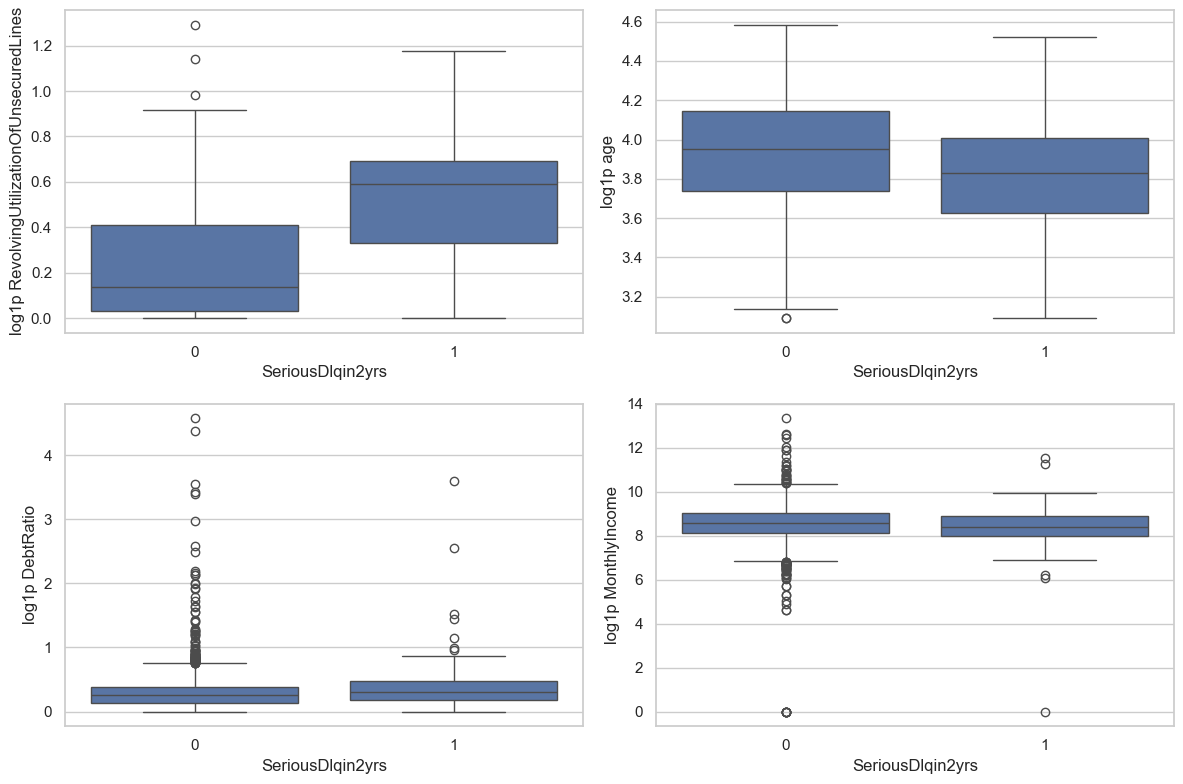

SeriousDlqin2yrs,0,1
NumberOfTime30-59DaysPastDueNotWorse,,
0,0.956466,0.043534
1,0.854701,0.145299
2,0.713415,0.286585


SeriousDlqin2yrs,0,1
NumberOfOpenCreditLinesAndLoans,,
0,0.625000,0.375000
1,0.805556,0.194444
2,0.935743,0.064257


SeriousDlqin2yrs,0,1
NumberOfTimes90DaysLate,,
0,0.949627,0.050373
1,0.752941,0.247059
2,0.385714,0.614286


SeriousDlqin2yrs,0,1
NumberRealEstateLoansOrLines,,
0,0.922528,0.077472
1,0.936946,0.063054
2,0.929678,0.070322


SeriousDlqin2yrs,0,1
NumberOfTime60-89DaysPastDueNotWorse,,
0,0.947133,0.052867
1,0.677966,0.322034
2,0.387097,0.612903


SeriousDlqin2yrs,0,1
NumberOfDependents,,
0,0.940562,0.059438
1,0.941667,0.058333
2,0.896307,0.103693


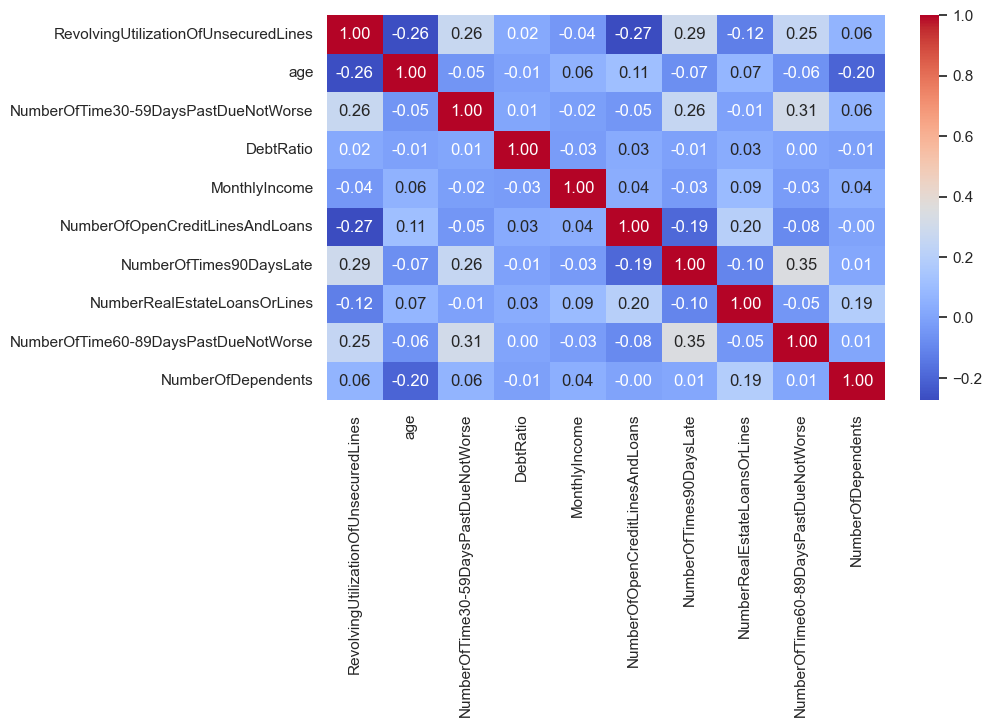

El umbral se aplica a varianza (diagonal de covarianza), tras escalar; no a unidades monetarias brutas.


RevolvingUtilizationOfUnsecuredLines    224.566706
age                                      35.177218
DebtRatio                                 0.935166
MonthlyIncome                             1.010235
Name: F_ANOVA, dtype: float64

NumberOfTimes90DaysLate                 0.032215
NumberOfTime60-89DaysPastDueNotWorse    0.024688
NumberOfTime30-59DaysPastDueNotWorse    0.021672
NumberOfOpenCreditLinesAndLoans         0.005583
NumberOfDependents                      0.002624
NumberRealEstateLoansOrLines            0.000281
Name: MI, dtype: float64

NumberOfTime60-89DaysPastDueNotWorse    5
NumberOfTimes90DaysLate                 5
RevolvingUtilizationOfUnsecuredLines    5
NumberOfTime30-59DaysPastDueNotWorse    4
age                                     4
DebtRatio                               2
NumberOfDependents                      2
NumberOfOpenCreditLinesAndLoans         2
NumberRealEstateLoansOrLines            2
MonthlyIncome                           1
Name: votos, dtype: int64

,metodo,features,n
0,Visual,"[RevolvingUtilizationOfUnsecuredLines, age, Nu...",8
1,ANOVA_MI,"[RevolvingUtilizationOfUnsecuredLines, age, Mo...",6
2,SFM,"[RevolvingUtilizationOfUnsecuredLines, age, Nu...",6
3,RFE,"[RevolvingUtilizationOfUnsecuredLines, age, Nu...",6
4,SFS,"[RevolvingUtilizationOfUnsecuredLines, NumberO...",6
5,Voting,"[NumberOfTime60-89DaysPastDueNotWorse, NumberO...",5


,seleccion,modelo,CV,std,n
1,Visual,RandomForest,0.779215,0.017745,8
0,Visual,Logistica,0.772650,0.025268,8
16,Voting,RandomForest,0.772056,0.021087,5
7,SFM,RandomForest,0.771594,0.021861,6
10,RFE,RandomForest,0.771594,0.021861,6
4,ANOVA_MI,RandomForest,0.770456,0.028808,6
6,SFM,Logistica,0.770068,0.021160,6
9,RFE,Logistica,0.770068,0.021160,6
15,Voting,Logistica,0.769336,0.018515,5
3,ANOVA_MI,Logistica,0.767349,0.020258,6


Ganador: RandomForest Visual features: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']
Parámetros: {'model__max_depth': 6, 'model__min_samples_leaf': 5} CV optimización: 0.7778407210528434 test: 0.7643586173629915
              precision    recall  f1-score   support

           0       0.98      0.78      0.86      2198
           1       0.20      0.75      0.32       166

    accuracy                           0.77      2364
   macro avg       0.59      0.76      0.59      2364
weighted avg       0.92      0.77      0.83      2364



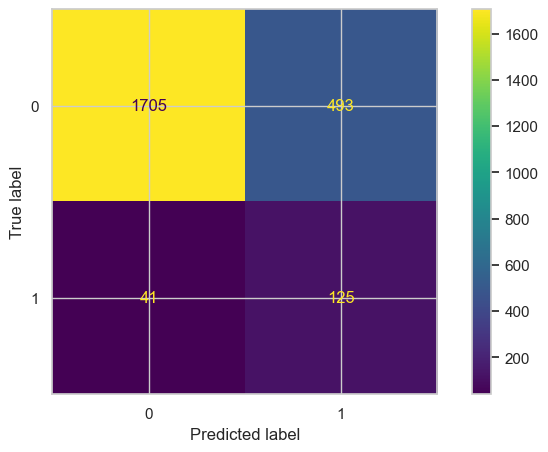

La CV sirve para elegir y optimizar, no como estimación imparcial tras 18 comparaciones. Test se conserva hasta la evaluación final. Las listas usan solo X_select; el modelo final se reajusta con todo train. El umbral de probabilidad es 0.5, sin optimizarlo en test.


In [2]:
raw=pd.read_csv('data/credit_npo.csv')
display(raw.head()); display(raw.isna().sum())
df=raw.dropna().copy()
print('Filas iniciales y completas:',len(raw),len(df))
target='SeriousDlqin2yrs'
cat_cols=[c for c in df if c.startswith('NumberOf') or c=='NumberRealEstateLoansOrLines']
# Tres niveles ordenados, con reglas fijas sin estimar a partir del target.
for c in cat_cols: df[c]=np.minimum(df[c],2).astype(int)
num_cols=[c for c in df if c not in cat_cols+[target]]
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns=target),df[target],test_size=.2,stratify=df[target],random_state=SEED)
# Subconjunto independiente para definir seis listas fijas. La CV de comparación no ve estas filas.
X_select,X_compare,y_select,y_compare=train_test_split(X_train,y_train,test_size=.7,stratify=y_train,random_state=SEED)
assert set(X_select.index).isdisjoint(X_compare.index)
assert set(X_train.index).isdisjoint(X_test.index)
display(y_train.value_counts(normalize=True))
print('Balanced accuracy evita que la clase mayoritaria domine. Selección:',len(X_select),'comparación:',len(X_compare),'test:',len(X_test))
fig,axes=plt.subplots(2,2,figsize=(12,8))
for c,ax in zip(num_cols,axes.flat):
    sns.boxplot(x=y_select,y=np.log1p(X_select[c]),ax=ax); ax.set_ylabel('log1p '+c)
plt.tight_layout(); plt.show()
for c in cat_cols: display(pd.crosstab(X_select[c],y_select,normalize='index'))
sns.heatmap(X_select.corr(),annot=True,fmt='.2f',cmap='coolwarm'); plt.show()
# 1. Variables plausibles visualmente; filtro de varianza y redundancia en escala [0,1].
scaled=MinMaxScaler().fit_transform(X_select)
var=VarianceThreshold(.001).fit(scaled)
candidate=X_select.columns[var.get_support()].tolist()
corr=X_select.corr().abs(); visual=[]
for c in candidate:
    if all(corr.loc[c,p]<.85 for p in visual): visual.append(c)
if not visual: raise ValueError('Ninguna variable supera el umbral de varianza')
print('El umbral se aplica a varianza (diagonal de covarianza), tras escalar; no a unidades monetarias brutas.')
# 2. ANOVA numéricas y MI discretas: hasta tres de cada grupo.
anova=SelectKBest(f_classif,k=min(3,len(num_cols))).fit(X_select[num_cols],y_select)
num_selected=np.array(num_cols)[anova.get_support()].tolist()
mi=pd.Series(mutual_info_classif(X_select[cat_cols],y_select,discrete_features=True,random_state=SEED),index=cat_cols).sort_values(ascending=False)
filter_features=num_selected+mi.head(3).index.tolist()
display(pd.Series(anova.scores_,index=num_cols,name='F_ANOVA')); display(mi.rename('MI'))
# 3. Modelo intermedio, máximo seis variables.
proxy=RandomForestClassifier(n_estimators=100,max_depth=5,class_weight='balanced',random_state=SEED)
sfm=SelectFromModel(proxy,threshold=-np.inf,max_features=6).fit(X_select,y_select)
model_features=X_select.columns[sfm.get_support()].tolist()
# 4. RFE, máximo seis.
rfe=RFE(clone(proxy),n_features_to_select=6).fit(X_select,y_select)
rfe_features=X_select.columns[rfe.get_support()].tolist()
# 5. SFS con un árbol proxy e inner-CV, dentro del conjunto de selección.
sfs=SequentialFeatureSelector(DecisionTreeClassifier(max_depth=4,min_samples_leaf=30,class_weight='balanced',random_state=SEED),n_features_to_select=6,
    cv=StratifiedKFold(3,shuffle=True,random_state=SEED),scoring='balanced_accuracy').fit(X_select,y_select)
sfs_features=X_select.columns[sfs.get_support()].tolist()
feature_sets={'Visual':visual,'ANOVA_MI':filter_features,'SFM':model_features,'RFE':rfe_features,'SFS':sfs_features}
# 6. Mayoría de >=3 votos; si hay >6 se desempata por votos y nombre.
votes=pd.Series({c:sum(c in values for values in feature_sets.values()) for c in X_train}).sort_index().sort_values(ascending=False,kind='stable')
voted=votes[votes>=3].head(6).index.tolist()
assert voted, 'No hay mayoría: revisar las listas de selección'
feature_sets['Voting']=voted
assert all(0<len(v)<=6 for k,v in feature_sets.items() if k!='Visual')
display(votes.rename('votos')); display(pd.DataFrame({'metodo':feature_sets.keys(),'features':list(feature_sets.values()),'n':[len(v) for v in feature_sets.values()]}))
models={
 'Logistica':LogisticRegression(max_iter=3000,class_weight='balanced',random_state=SEED),
 'RandomForest':RandomForestClassifier(n_estimators=150,max_depth=6,min_samples_leaf=10,class_weight='balanced',random_state=SEED),
 'HistGradientBoosting':HistGradientBoostingClassifier(max_iter=150,max_leaf_nodes=15,class_weight='balanced',random_state=SEED)}
def preprocessing(features):
    nums=[c for c in features if c in num_cols]; cats=[c for c in features if c in cat_cols]
    return ColumnTransformer([
       ('num',make_pipeline(FunctionTransformer(np.log1p,feature_names_out='one-to-one'),StandardScaler()),nums),
       ('cat',OneHotEncoder(handle_unknown='ignore',sparse_output=False),cats)])
comparison=[]; pipelines={}
for selection,features in feature_sets.items():
    for model_name,model in models.items():
        pipe=Pipeline([('preprocess',preprocessing(features)),('model',clone(model))])
        scores=cross_val_score(pipe,X_compare,y_compare,cv=cv,scoring='balanced_accuracy')
        comparison.append({'seleccion':selection,'modelo':model_name,'CV':scores.mean(),'std':scores.std(),'n':len(features)})
        pipelines[(selection,model_name)]=pipe
comparison=pd.DataFrame(comparison).sort_values(['CV','n'],ascending=[False,True])
assert len(comparison)==18
display(comparison)
best=comparison.iloc[0]; selected_features=feature_sets[best.seleccion]
grids={
 'Logistica':{'model__C':[.1,1,10]},
 'RandomForest':{'model__max_depth':[4,6,10],'model__min_samples_leaf':[5,15]},
 'HistGradientBoosting':{'model__max_leaf_nodes':[7,15,31],'model__learning_rate':[.05,.1]}}
search=GridSearchCV(pipelines[(best.seleccion,best.modelo)],grids[best.modelo],cv=cv,scoring='balanced_accuracy')
search.fit(X_compare,y_compare)
final_model=clone(search.best_estimator_).fit(X_train,y_train)
prediction=final_model.predict(X_test)
final_score=balanced_accuracy_score(y_test,prediction)
print('Ganador:',best.modelo,best.seleccion,'features:',selected_features)
print('Parámetros:',search.best_params_,'CV optimización:',search.best_score_,'test:',final_score)
print(classification_report(y_test,prediction,zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test,prediction); plt.show()
print('La CV sirve para elegir y optimizar, no como estimación imparcial tras 18 comparaciones. Test se conserva hasta la evaluación final. Las listas usan solo X_select; el modelo final se reajusta con todo train. El umbral de probabilidad es 0.5, sin optimizarlo en test.')

### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.

In [3]:
pca_model=Pipeline([('preprocess',preprocessing(X_train.columns.tolist())),
                    ('pca',PCA(n_components=.95,svd_solver='full')),
                    ('model',clone(final_model.named_steps['model']))])
pca_cv=cross_val_score(pca_model,X_train,y_train,cv=cv,scoring='balanced_accuracy')
pca_model.fit(X_train,y_train)
pca_score=balanced_accuracy_score(y_test,pca_model.predict(X_test))
display(pd.DataFrame([
 {'metodo':'Selección ganadora','variables_originales':len(selected_features),'dimensiones_modelo':final_model.named_steps['preprocess'].transform(X_test).shape[1],'test':final_score},
 {'metodo':'PCA 95%','variables_originales':X_train.shape[1],'dimensiones_modelo':pca_model.named_steps['pca'].n_components_,'test':pca_score}]))
print('PCA CV:',pca_cv.mean(),'varianza retenida:',pca_model.named_steps['pca'].explained_variance_ratio_.sum())
print('Delta test PCA frente a selección:',pca_score-final_score)
print('PCA transforma todas las variables: reduce dimensiones pero requiere medirlas todas y pierde interpretación. La comparación de test del extra es descriptiva, no una nueva ronda de ajuste.')

,metodo,variables_originales,dimensiones_modelo,test
0,Selección ganadora,8,20,0.764359
1,PCA 95%,10,10,0.769026


PCA CV: 0.7658392850532321 varianza retenida: 0.9619507069961178
Delta test PCA frente a selección: 0.004667441376059345
PCA transforma todas las variables: reduce dimensiones pero requiere medirlas todas y pierde interpretación. La comparación de test del extra es descriptiva, no una nueva ronda de ajuste.


### Conclusión de la comparación

La mejor combinación por CV es Random Forest con la selección visual y filtros (8 variables, permitidas por la excepción del apartado 1): balanced accuracy 0.7792 antes de optimizar y 0.7644 en test tras optimización. El hard voting propone 5 variables con CV 0.7721: es una alternativa más sencilla cuya diferencia de CV es pequeña frente a la dispersión entre folds, aunque aquí se mantiene la ganadora por la regla definida.

El recall de impago en test ronda el 75%, pero su precisión es aproximadamente 20%; por tanto, identificar más impagos conlleva muchos falsos positivos. No basta con la accuracy global para decidir su utilidad. PCA ofrece 0.7690 en test, una mejora descriptiva de 0.47 puntos, pero exige todas las variables originales y pierde interpretación. No se utiliza esa consulta adicional de test para cambiar el modelo ganador.